# IMC Prosperity Round 4 — Manual Trading: AETHER_CRYSTAL

**Objective:** Maximize average PnL across 100 GBM simulations. Positions set at t=0, held to expiry.

| Parameter | Value |
|-----------|-------|
| S₀ | 50 |
| σ | 251% annualized |
| Drift | 0 (risk-neutral) |
| Steps/day | 4 |
| Days/year | 252 |
| 2-week expiry | 40 steps |
| 3-week expiry | 60 steps |
| Contract size | 3000 (PnL multiplier) |
| Scoring | avg PnL over 100 sims |

**Key strategies identified:**
1. **Chooser arb** (near-riskless): Sell Chooser + Buy 3wk Call + Buy 2wk Put via put-call parity
2. **Binary Put sell**: Overpriced by ~0.23 vs fair value
3. **2wk Call/Put buy**: Both underpriced by ~0.11-0.13
4. **KO Put buy**: Fair ≈ 0.206 vs ask 0.175 — positive edge at max volume
5. **60C sell**: Fair ≈ 8.75 vs bid 8.80 — slight edge

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Constants ────────────────────────────────────────────────────
S0            = 50.0
SIGMA         = 2.51          # 251% annualized
TRADING_DAYS  = 252
STEPS_PER_DAY = 4
STEPS_PER_YEAR = TRADING_DAYS * STEPS_PER_DAY   # 1008
CONTRACT_SIZE = 3000

def weeks_to_years(w): return (w * 5) / TRADING_DAYS
def steps_for_weeks(w): return int(round(w * 5 * STEPS_PER_DAY))

T2, T3     = weeks_to_years(2), weeks_to_years(3)
STEPS_2W   = steps_for_weeks(2)   # 40
STEPS_3W   = steps_for_weeks(3)   # 60

print(f'σ/step = {SIGMA/np.sqrt(STEPS_PER_YEAR):.5f}')
print(f'2wk: T={T2:.6f} yrs | {STEPS_2W} steps')
print(f'3wk: T={T3:.6f} yrs | {STEPS_3W} steps')

σ/step = 0.07906
2wk: T=0.039683 yrs | 40 steps
3wk: T=0.059524 yrs | 60 steps


## 1 — GBM Simulation Engine

E[S_2w] = 49.9800  (should ≈ 50.0, martingale check)
E[S_3w] = 49.9497
P(S_3w < 50) = 0.6205  (lognormal: > 0.5 expected due to skew)


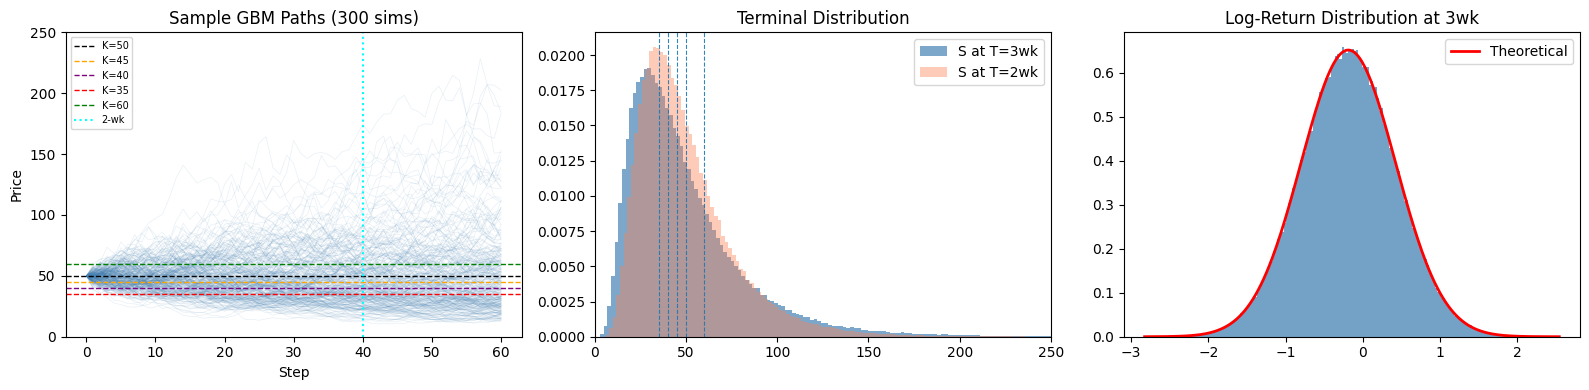

In [ ]:
def simulate_paths(S0, sigma, n_sims, n_steps, steps_per_year=STEPS_PER_YEAR, seed=0):
    """
    Discrete GBM: dlog(S) = -σ²/2·dt + σ·√dt·Z
    Returns (n_sims, n_steps+1) price matrix.
    """
    rng  = np.random.default_rng(seed)
    dt   = 1.0 / steps_per_year
    Z    = rng.standard_normal((n_sims, n_steps))
    dlog = -0.5 * sigma**2 * dt + sigma * np.sqrt(dt) * Z
    lp   = np.zeros((n_sims, n_steps + 1))
    lp[:, 1:] = np.cumsum(dlog, axis=1)
    return S0 * np.exp(lp)

# High-accuracy paths for fair value estimation
N_FAIR = 300_000
paths  = simulate_paths(S0, SIGMA, N_FAIR, STEPS_3W, seed=42)
S2     = paths[:, STEPS_2W]     # prices at 2-week mark
S3     = paths[:, STEPS_3W]     # prices at 3-week expiry
Smin   = paths.min(axis=1)      # path minimum (discrete, for KO barrier)

print(f'E[S_2w] = {S2.mean():.4f}  (should ≈ 50.0, martingale check)')
print(f'E[S_3w] = {S3.mean():.4f}')
print(f'P(S_3w < 50) = {np.mean(S3 < 50):.4f}  (lognormal: > 0.5 expected due to skew)')

# ── Path visualisation ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sample paths
sample = simulate_paths(S0, SIGMA, 300, STEPS_3W, seed=99)
for p in sample:
    axes[0].plot(p, alpha=0.12, linewidth=0.5, color='steelblue')
for k, c, ls in [(50,'black','--'), (45,'orange','--'), (40,'purple','--'), (35,'red','--'), (60,'green','--')]:
    axes[0].axhline(k, color=c, linewidth=1, linestyle=ls, label=f'K={k}')
axes[0].axvline(STEPS_2W, color='cyan', linewidth=1.5, linestyle=':', label='2-wk')
axes[0].set_title('Sample GBM Paths (300 sims)'); axes[0].set_xlabel('Step'); axes[0].set_ylabel('Price')
axes[0].set_ylim(0, 250); axes[0].legend(fontsize=7)

# Terminal distribution
axes[1].hist(np.clip(S3, 0, 400), bins=200, density=True, alpha=0.7, color='steelblue', label='S at T=3wk')
axes[1].hist(np.clip(S2, 0, 400), bins=200, density=True, alpha=0.4, color='coral', label='S at T=2wk')
for k in [35,40,45,50,60]:
    axes[1].axvline(k, linestyle='--', linewidth=0.8, alpha=0.9)
axes[1].set_xlim(0, 250); axes[1].set_title('Terminal Distribution'); axes[1].legend()

# Log-return distribution
log_ret = np.log(S3 / S0)
axes[2].hist(log_ret, bins=200, density=True, color='steelblue', alpha=0.75)
x = np.linspace(log_ret.min(), log_ret.max(), 300)
axes[2].plot(x, norm.pdf(x, -0.5*SIGMA**2*T3, SIGMA*np.sqrt(T3)), 'r-', linewidth=2, label='Theoretical')
axes[2].set_title('Log-Return Distribution at 3wk'); axes[2].legend()
plt.tight_layout(); plt.show()

## 2 — Black-Scholes Analytical Fair Values

In [3]:
def bs_call(S, K, T, sig, r=0):
    if T <= 0: return float(max(S - K, 0))
    d1 = (np.log(S/K) + (r + 0.5*sig**2)*T) / (sig*np.sqrt(T))
    d2 = d1 - sig*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_put(S, K, T, sig, r=0):
    if T <= 0: return float(max(K - S, 0))
    d1 = (np.log(S/K) + (r + 0.5*sig**2)*T) / (sig*np.sqrt(T))
    d2 = d1 - sig*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_binary_put(S, K, T, sig, payout=10, r=0):
    """Cash-or-nothing: pays payout if S_T < K."""
    d2 = (np.log(S/K) + (r - 0.5*sig**2)*T) / (sig*np.sqrt(T))
    return payout * np.exp(-r*T) * norm.cdf(-d2)

def chooser_bs(S, K, T_choice, T_expiry, sig, r=0):
    """
    At T_choice, holder picks call or put; option expires at T_expiry.
    Decomposition (r=0): C(K,T_expiry) + P(K,T_choice)
    Proof via P-C parity: max(C,P) = C + max(K-S,0)
    """
    return bs_call(S, K, T_expiry, sig, r) + bs_put(S, K, T_choice, sig, r)

bs_fv = {
    'AC_50_C':   bs_call(S0, 50, T3, SIGMA),
    'AC_50_P':   bs_put(S0,  50, T3, SIGMA),
    'AC_35_P':   bs_put(S0,  35, T3, SIGMA),
    'AC_40_P':   bs_put(S0,  40, T3, SIGMA),
    'AC_45_P':   bs_put(S0,  45, T3, SIGMA),
    'AC_60_C':   bs_call(S0, 60, T3, SIGMA),
    'AC_50_C_2': bs_call(S0, 50, T2, SIGMA),
    'AC_50_P_2': bs_put(S0,  50, T2, SIGMA),
    'AC_50_CO':  chooser_bs(S0, 50, T2, T3, SIGMA),
    'AC_40_BP':  bs_binary_put(S0, 40, T3, SIGMA, 10),
}

print(f'\n{"Product":<14} {"BS Fair":>10}')
print('-' * 28)
for k, v in bs_fv.items():
    print(f'{k:<14} {v:>10.4f}')

print(f'\nChooser = Call(T3) + Put(T2):')
print(f'  {bs_call(S0,50,T3,SIGMA):.4f} + {bs_put(S0,50,T2,SIGMA):.4f} = {chooser_bs(S0,50,T2,T3,SIGMA):.4f}')
print(f'  Market ask = 22.300  =>  Sell edge = {22.2 - chooser_bs(S0,50,T2,T3,SIGMA):.4f}')


Product           BS Fair
----------------------------
AC_50_C           12.0269
AC_50_P           12.0269
AC_35_P            4.3361
AC_40_P            6.5095
AC_45_P            9.0889
AC_60_C            8.7918
AC_50_C_2          9.8707
AC_50_P_2          9.8707
AC_50_CO          21.8977
AC_40_BP           4.7679

Chooser = Call(T3) + Put(T2):
  12.0269 + 9.8707 = 21.8977
  Market ask = 22.300  =>  Sell edge = 0.3023


## 3 — Monte Carlo Fair Values (300k sims)

In [4]:
def compute_mc_fair_values(paths, STEPS_2W, STEPS_3W):
    S2   = paths[:, STEPS_2W]
    S3   = paths[:, STEPS_3W]
    Smin = paths.min(axis=1)   # discrete minimum across all 60 steps

    fv = {}
    # 3-week vanillas
    fv['AC_50_C']   = np.mean(np.maximum(S3 - 50, 0))
    fv['AC_50_P']   = np.mean(np.maximum(50 - S3, 0))
    fv['AC_35_P']   = np.mean(np.maximum(35 - S3, 0))
    fv['AC_40_P']   = np.mean(np.maximum(40 - S3, 0))
    fv['AC_45_P']   = np.mean(np.maximum(45 - S3, 0))
    fv['AC_60_C']   = np.mean(np.maximum(S3 - 60, 0))
    # 2-week vanillas
    fv['AC_50_C_2'] = np.mean(np.maximum(S2 - 50, 0))
    fv['AC_50_P_2'] = np.mean(np.maximum(50 - S2, 0))
    # Chooser: at T2, holder picks whichever is ITM
    fv['AC_50_CO']  = np.mean(np.where(S2 >= 50,
                                        np.maximum(S3 - 50, 0),
                                        np.maximum(50 - S3, 0)))
    # Binary put: pays 10 if S3 < 40
    fv['AC_40_BP']  = np.mean(10.0 * (S3 < 40))
    # KO put: K=45, barrier=35; worthless if min(path) ≤ 35 (discrete)
    fv['AC_45_KO']  = np.mean(np.where(Smin > 35, np.maximum(45 - S3, 0), 0.0))

    return fv

mc_fv = compute_mc_fair_values(paths, STEPS_2W, STEPS_3W)

# Market prices
market = {
    'AC_50_C':   {'bid':12.000,'ask':12.050,'vol':50},
    'AC_50_P':   {'bid':12.000,'ask':12.050,'vol':50},
    'AC_35_P':   {'bid': 4.330,'ask': 4.350,'vol':50},
    'AC_40_P':   {'bid': 6.500,'ask': 6.550,'vol':50},
    'AC_45_P':   {'bid': 9.050,'ask': 9.100,'vol':50},
    'AC_60_C':   {'bid': 8.800,'ask': 8.850,'vol':50},
    'AC_50_C_2': {'bid': 9.700,'ask': 9.750,'vol':50},
    'AC_50_P_2': {'bid': 9.700,'ask': 9.750,'vol':50},
    'AC_50_CO':  {'bid':22.200,'ask':22.300,'vol':50},
    'AC_40_BP':  {'bid': 5.000,'ask': 5.100,'vol':50},
    'AC_45_KO':  {'bid': 0.150,'ask': 0.175,'vol':500},
}

print(f'{"Product":<14} {"MC Fair":>9} {"BS Fair":>9} {"Bid":>7} {"Ask":>7} {"EdgeBuy":>9} {"EdgeSell":>9} {"Signal"}')
print('-' * 80)
for k, m in market.items():
    fv   = mc_fv.get(k, 0)
    bs   = bs_fv.get(k, None)
    eb   = fv - m['ask']
    es   = m['bid'] - fv
    sig  = '◀ BUY' if eb > 0.05 else ('▶ SELL' if es > 0.05 else '  FAIR')
    bss  = f'{bs:.4f}' if bs else '   N/A'
    print(f'{k:<14} {fv:>9.4f} {bss:>9} {m["bid"]:>7.3f} {m["ask"]:>7.3f} {eb:>9.4f} {es:>9.4f}  {sig}')

print(f'\nKO Barrier analysis:')
print(f'  P(min path > 35)              = {np.mean(Smin > 35):.4f}')
print(f'  P(survive AND ITM at 3wk)     = {np.mean((Smin > 35) & (S3 < 45)):.4f}')
print(f'  P(min path ≤ 35, knocked out) = {np.mean(Smin <= 35):.4f}')

Product          MC Fair   BS Fair     Bid     Ask   EdgeBuy  EdgeSell Signal
--------------------------------------------------------------------------------
AC_50_C          11.9789   12.0269  12.000  12.050   -0.0711    0.0211    FAIR
AC_50_P          12.0293   12.0269  12.000  12.050   -0.0207   -0.0293    FAIR
AC_35_P           4.3385    4.3361   4.330   4.350   -0.0115   -0.0085    FAIR
AC_40_P           6.5114    6.5095   6.500   6.550   -0.0386   -0.0114    FAIR
AC_45_P           9.0900    9.0889   9.050   9.100   -0.0100   -0.0400    FAIR
AC_60_C           8.7465    8.7918   8.800   8.850   -0.1035    0.0535  ▶ SELL
AC_50_C_2         9.8553    9.8707   9.700   9.750    0.1053   -0.1553  ◀ BUY
AC_50_P_2         9.8753    9.8707   9.700   9.750    0.1253   -0.1753  ◀ BUY
AC_50_CO         21.8663   21.8977  22.200  22.300   -0.4337    0.3337  ▶ SELL
AC_40_BP          4.7686    4.7679   5.000   5.100   -0.3314    0.2314  ▶ SELL
AC_45_KO          0.2064       N/A   0.150   0.175   

## 4 — Chooser Arbitrage (Core Trade)

**Theorem (r=0):** `Chooser(K, T₁→T₃) = Call(K, T₃) + Put(K, T₁)`

At T₁: holder picks `max(C, P) = C + max(0, K-S)` = Call(T₃) + Put(T₁) by P-C parity.

**Trade:** Sell Chooser @ 22.20 + Buy 3wk Call @ 12.05 + Buy 2wk Put @ 9.75
- Net premium locked: `22.20 - 12.05 - 9.75 = +0.40/unit`
- Replication payoff cancels exactly → **pure arb premium**

Chooser Replication Verification:
  Net payoff mean  : -0.011972  (≈ 0 → perfect hedge)
  Net payoff std   : 9.7769   (residual from discrete steps)
  Arb premium      : 0.4000
  Total PnL/unit   : 0.3880  (= premium + hedge residual)
  Total PnL std    : 9.7769
  P(PnL > 0)       : 0.6679

Case analysis:
  S2≥50 (chooser→call): N=120616, net_payoff mean=0.000000
  S2<50  (chooser→put):  N=179384, net_payoff mean=-0.020022


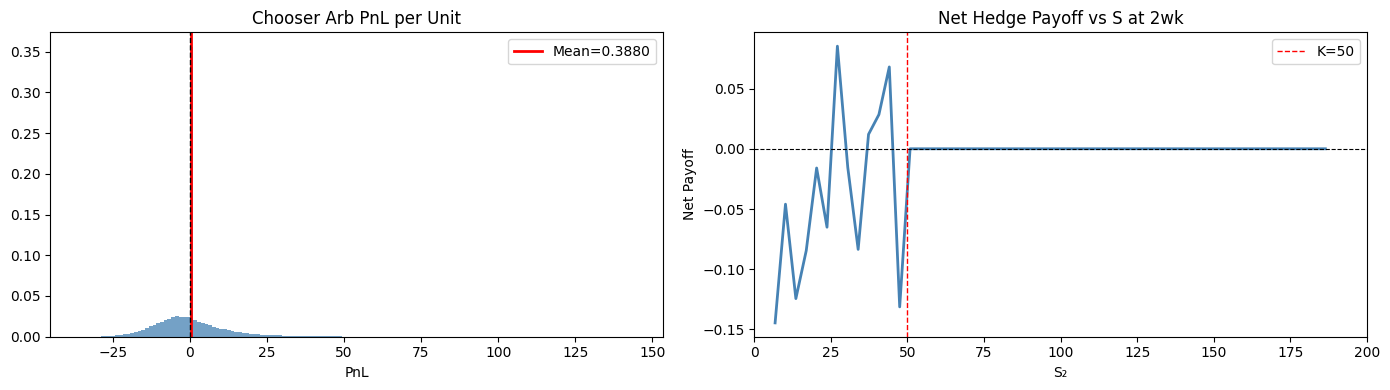


50 contracts × 3000: E[PnL] = 58,204


In [5]:
# ── Verify replication ────────────────────────────────────────────
long_call_3w  = np.maximum(S3 - 50, 0)
long_put_2w   = np.maximum(50 - S2, 0)
short_chooser = -np.where(S2 >= 50,
                           np.maximum(S3 - 50, 0),
                           np.maximum(50 - S3, 0))
net_payoff    = long_call_3w + long_put_2w + short_chooser

arb_premium = 22.20 - 12.05 - 9.75   # received (positive)
total_pnl   = arb_premium + net_payoff

print('Chooser Replication Verification:')
print(f'  Net payoff mean  : {net_payoff.mean():.6f}  (≈ 0 → perfect hedge)')
print(f'  Net payoff std   : {net_payoff.std():.4f}   (residual from discrete steps)')
print(f'  Arb premium      : {arb_premium:.4f}')
print(f'  Total PnL/unit   : {total_pnl.mean():.4f}  (= premium + hedge residual)')
print(f'  Total PnL std    : {total_pnl.std():.4f}')
print(f'  P(PnL > 0)       : {(total_pnl > 0).mean():.4f}')

print('\nCase analysis:')
# Case 1: S2 >= 50, chooser becomes call
mask_call = S2 >= 50
res_call  = long_call_3w[mask_call] + long_put_2w[mask_call] + short_chooser[mask_call]
print(f'  S2≥50 (chooser→call): N={mask_call.sum()}, net_payoff mean={res_call.mean():.6f}')
# Case 2: S2 < 50, chooser becomes put
mask_put  = S2 < 50
res_put   = long_call_3w[mask_put] + long_put_2w[mask_put] + short_chooser[mask_put]
print(f'  S2<50  (chooser→put):  N={mask_put.sum()}, net_payoff mean={res_put.mean():.6f}')

# ── PnL distribution ─────────────────────────────────────────────
vol_arb = 50
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(total_pnl, bins=150, density=True, color='steelblue', alpha=0.75)
axes[0].axvline(total_pnl.mean(), color='red', linewidth=2, label=f'Mean={total_pnl.mean():.4f}')
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Chooser Arb PnL per Unit')
axes[0].set_xlabel('PnL'); axes[0].legend()

# Net payoff by S2 value
s2_bins = np.linspace(0, 200, 60)
bin_idx  = np.digitize(S2, s2_bins)
bin_mean = [net_payoff[bin_idx == i].mean() if (bin_idx == i).sum() > 50 else np.nan
            for i in range(1, len(s2_bins))]
axes[1].plot(s2_bins[:-1], bin_mean, 'steelblue', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(50, color='red', linewidth=1, linestyle='--', label='K=50')
axes[1].set_title('Net Hedge Payoff vs S at 2wk')
axes[1].set_xlabel('S₂'); axes[1].set_ylabel('Net Payoff'); axes[1].legend()
axes[1].set_xlim(0, 200)
plt.tight_layout(); plt.show()

print(f'\n50 contracts × 3000: E[PnL] = {total_pnl.mean() * vol_arb * CONTRACT_SIZE:,.0f}')

## 5 — Binary Put Analysis (AC_40_BP)

Binary Put (K=40, payout=10, T=3wk):
  MC Fair value        : 4.7686
  BS Fair value        : 4.7679
  P(S_3w < 40)         : 0.4769
  Market bid           : 5.0
  Edge (sell at bid)   : 0.2314/unit

  E[PnL/unit] sell @ bid : 0.2314
  Std                    : 4.9946
  P(PnL > 0)             : 0.5231
  Worst case per unit    : -5.0000  (pay 10, receive 5)

  50 contracts × 3000: E[PnL] = 34,705


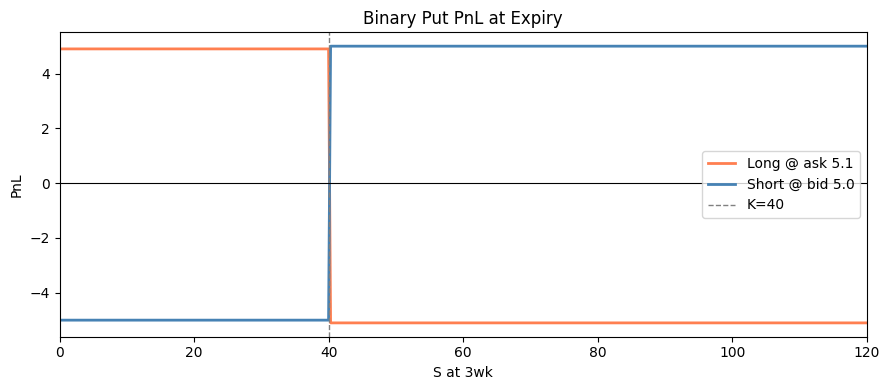

In [6]:
bp_fv   = mc_fv['AC_40_BP']
bp_bid, bp_ask = 5.000, 5.100

print('Binary Put (K=40, payout=10, T=3wk):')
print(f'  MC Fair value        : {bp_fv:.4f}')
print(f'  BS Fair value        : {bs_binary_put(S0, 40, T3, SIGMA, 10):.4f}')
print(f'  P(S_3w < 40)         : {np.mean(S3 < 40):.4f}')
print(f'  Market bid           : {bp_bid}')
print(f'  Edge (sell at bid)   : {bp_bid - bp_fv:.4f}/unit')

# Short binary put PnL
bp_payoff = -(10.0 * (S3 < 40))   # we pay this if S3 < 40
bp_total  = bp_bid + bp_payoff
print(f'\n  E[PnL/unit] sell @ bid : {bp_total.mean():.4f}')
print(f'  Std                    : {bp_total.std():.4f}')
print(f'  P(PnL > 0)             : {(bp_total > 0).mean():.4f}')
print(f'  Worst case per unit    : {bp_total.min():.4f}  (pay 10, receive 5)')

vol_bp = 50
print(f'\n  50 contracts × 3000: E[PnL] = {bp_total.mean() * vol_bp * CONTRACT_SIZE:,.0f}')

# Payoff diagram
fig, ax = plt.subplots(figsize=(9, 4))
spot = np.linspace(0, 150, 500)
long_payoff  = 10.0 * (spot < 40) - bp_ask   # long at ask
short_payoff = bp_bid - 10.0 * (spot < 40)   # short at bid
ax.plot(spot, long_payoff,  'coral',     linewidth=2, label=f'Long @ ask {bp_ask}')
ax.plot(spot, short_payoff, 'steelblue', linewidth=2, label=f'Short @ bid {bp_bid}')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(40, color='gray', linewidth=1, linestyle='--', label='K=40')
ax.set_title('Binary Put PnL at Expiry'); ax.set_xlabel('S at 3wk'); ax.set_ylabel('PnL')
ax.legend(); ax.set_xlim(0, 120)
plt.tight_layout(); plt.show()

## 6 — Knock-Out Put Deep Dive (AC_45_KO)

Knock-Out Put (K=45, barrier H=35, T=3wk, discrete monitoring):
  Vanilla put K=45 fair   : 9.0900
  KO put MC fair value    : 0.2064
  KO / Vanilla            : 0.0227  (probability weight)
  P(never hits H=35)      : 0.3856
  P(hits barrier)         : 0.6143
  P(survive AND ITM)      : 0.0491

  Market bid: 0.15  ask: 0.175
  Edge BUY  : 0.0314/unit  (pay ask)
  Edge SELL : -0.0564/unit  (receive bid)  — NEGATIVE, do not sell

  → BUY at ask = 0.175 (positive edge, max vol = 500)

  Long KO PnL stats:
  E[PnL/unit]   : 0.0314
  Std           : 1.0871
  P(PnL > 0)    : 0.0479
  500 contracts × 3000: E[PnL] = 47,044

Fair Value vs Barrier Level:
   Barrier   P(survive)         FV   Edge(buy@ask)
        28       0.5897     1.2606          1.0856
        30       0.5294     0.8153          0.6403
        32       0.4706     0.5000          0.3250
        34       0.4136     0.2826          0.1076
        35       0.3856     0.2064          0.0314
        36       0.3581     0.1472      

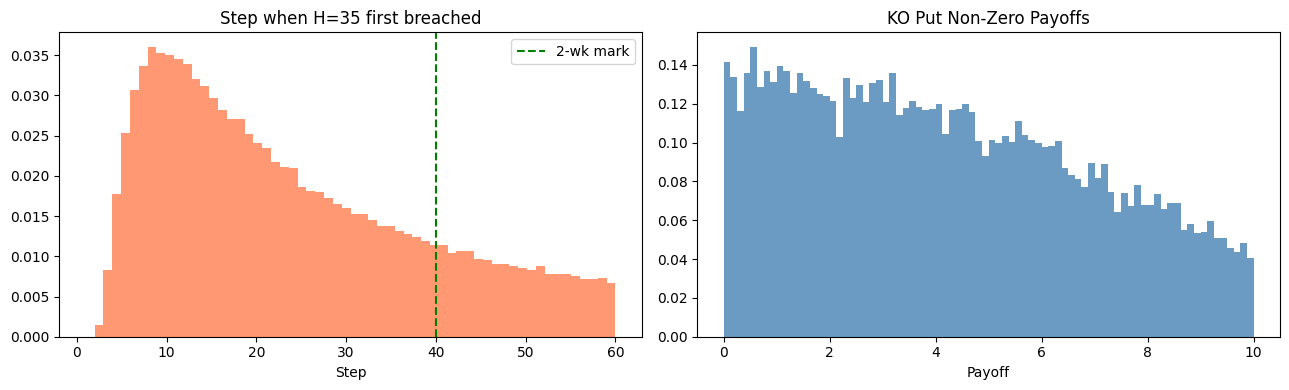

In [7]:
ko_fv          = mc_fv['AC_45_KO']
vanilla_put_fv = mc_fv['AC_45_P']
ko_bid, ko_ask = 0.150, 0.175

print('Knock-Out Put (K=45, barrier H=35, T=3wk, discrete monitoring):')
print(f'  Vanilla put K=45 fair   : {vanilla_put_fv:.4f}')
print(f'  KO put MC fair value    : {ko_fv:.4f}')
print(f'  KO / Vanilla            : {ko_fv/vanilla_put_fv:.4f}  (probability weight)')
print(f'  P(never hits H=35)      : {np.mean(Smin > 35):.4f}')
print(f'  P(hits barrier)         : {np.mean(Smin <= 35):.4f}')
print(f'  P(survive AND ITM)      : {np.mean((Smin > 35) & (S3 < 45)):.4f}')
print(f'\n  Market bid: {ko_bid}  ask: {ko_ask}')
print(f'  Edge BUY  : {ko_fv - ko_ask:.4f}/unit  (pay ask)')
print(f'  Edge SELL : {ko_bid - ko_fv:.4f}/unit  (receive bid)  — NEGATIVE, do not sell')
print(f'\n  → BUY at ask = 0.175 (positive edge, max vol = 500)')

ko_payoff_long = np.where(Smin > 35, np.maximum(45 - S3, 0), 0.0) - ko_ask
print(f'\n  Long KO PnL stats:')
print(f'  E[PnL/unit]   : {ko_payoff_long.mean():.4f}')
print(f'  Std           : {ko_payoff_long.std():.4f}')
print(f'  P(PnL > 0)    : {(ko_payoff_long > 0).mean():.4f}')
print(f'  500 contracts × 3000: E[PnL] = {ko_payoff_long.mean() * 500 * CONTRACT_SIZE:,.0f}')

# Barrier hit timing
breach_step = np.argmax(paths <= 35, axis=1)
breach_step[Smin > 35] = STEPS_3W + 1
breach_times = breach_step[Smin <= 35]

# Barrier sensitivity
print('\nFair Value vs Barrier Level:')
print(f'{"Barrier":>10} {"P(survive)":>12} {"FV":>10} {"Edge(buy@ask)":>15}')
for h in [28, 30, 32, 34, 35, 36, 38, 40]:
    ko_v  = np.mean(np.where(Smin > h, np.maximum(45-S3,0), 0.0))
    p_sur = np.mean(Smin > h)
    print(f'{h:>10} {p_sur:>12.4f} {ko_v:>10.4f} {ko_v-ko_ask:>15.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(breach_times, bins=60, density=True, color='coral', alpha=0.8)
axes[0].axvline(STEPS_2W, color='green', linestyle='--', label='2-wk mark')
axes[0].set_title('Step when H=35 first breached'); axes[0].set_xlabel('Step')
axes[0].legend()

ko_pos_payoffs = ko_payoff_long + ko_ask   # raw payoff (before cost)
axes[1].hist(ko_pos_payoffs[ko_pos_payoffs > 0], bins=80, density=True, color='steelblue', alpha=0.8)
axes[1].set_title('KO Put Non-Zero Payoffs'); axes[1].set_xlabel('Payoff')
plt.tight_layout(); plt.show()

## 7 — 2-Week ATM Straddle Analysis

2-Week ATM Options (K=50):
  Call fair = 9.8553  ask = 9.750  edge_buy = 0.1053
  Put  fair = 9.8753  ask = 9.750  edge_buy = 0.1253
  Straddle fair = 19.7307  cost = 19.500  edge = 0.2307
  P-C parity check: Call-Put = -0.0200  (should ≈ 0 for ATM r=0)

  Long call E[PnL/unit]: 0.1053
  Long put  E[PnL/unit]: 0.1253


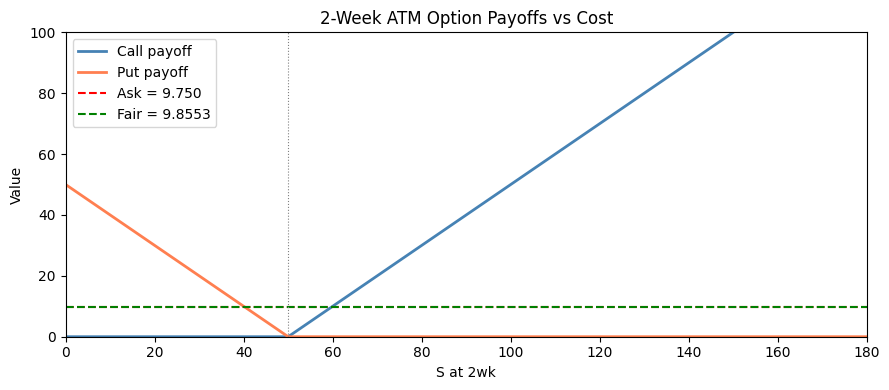

In [8]:
call2_fv = mc_fv['AC_50_C_2']
put2_fv  = mc_fv['AC_50_P_2']

print('2-Week ATM Options (K=50):')
print(f'  Call fair = {call2_fv:.4f}  ask = 9.750  edge_buy = {call2_fv - 9.750:.4f}')
print(f'  Put  fair = {put2_fv:.4f}  ask = 9.750  edge_buy = {put2_fv - 9.750:.4f}')
print(f'  Straddle fair = {call2_fv + put2_fv:.4f}  cost = 19.500  edge = {call2_fv + put2_fv - 19.5:.4f}')
print(f'  P-C parity check: Call-Put = {call2_fv - put2_fv:.4f}  (should ≈ 0 for ATM r=0)')

# Why buy call instead of put? (put slot used for arb)
call2_pnl = np.maximum(S2 - 50, 0) - 9.75
put2_pnl  = np.maximum(50 - S2, 0) - 9.75
print(f'\n  Long call E[PnL/unit]: {call2_pnl.mean():.4f}')
print(f'  Long put  E[PnL/unit]: {put2_pnl.mean():.4f}')

# Payoff diagram vs fair value breakeven
fig, ax = plt.subplots(figsize=(9, 4))
spot = np.linspace(0, 200, 500)
ax.plot(spot, np.maximum(spot-50, 0), 'steelblue', linewidth=2, label='Call payoff')
ax.plot(spot, np.maximum(50-spot, 0), 'coral',     linewidth=2, label='Put payoff')
ax.axhline(9.750,    color='red',   linestyle='--', linewidth=1.5, label=f'Ask = 9.750')
ax.axhline(call2_fv, color='green', linestyle='--', linewidth=1.5, label=f'Fair = {call2_fv:.4f}')
ax.axvline(50, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlim(0, 180); ax.set_ylim(0, 100)
ax.set_title('2-Week ATM Option Payoffs vs Cost')
ax.set_xlabel('S at 2wk'); ax.set_ylabel('Value')
ax.legend(); plt.tight_layout(); plt.show()

## 8 — Optimal Portfolio Construction

In [9]:
# ─────────────────────────────────────────────────────────────────
# FINAL POSITION RATIONALE
# ─────────────────────────────────────────────────────────────────
# 1. CHOOSER ARB (near-riskless) ─ Sell 50 chooser @ 22.20
#    + Buy 50 3wk call @ 12.05  } replication portfolio:
#    + Buy 50 2wk put  @ 9.75   } net payoff ≈ 0, premium = +0.40/unit
#    NOTE: 3wk CALL is slightly overpriced here but its overpricing is
#    offset by the chooser premium. Net arb edge dominates.
#
# 2. BINARY PUT SELL ─ Sell 50 @ 5.00 (fair ≈ 4.77, edge +0.23)
#
# 3. 2WK CALL BUY ─ Buy 50 @ 9.75 (fair ≈ 9.86, edge +0.11)
#    (2wk put slot is taken by arb leg)
#
# 4. KO PUT BUY ─ Buy 500 @ 0.175 (fair ≈ 0.206, edge +0.031)
#    Large volume makes this meaningful despite small per-unit edge
#
# 5. 60C SELL ─ Sell 50 @ 8.80 (fair ≈ 8.75, edge +0.05)
# ─────────────────────────────────────────────────────────────────

positions = {
    'AC_50_CO':  {'dir': -1, 'vol':  50, 'price': 22.200},  # SELL chooser
    'AC_50_C':   {'dir': +1, 'vol':  50, 'price': 12.050},  # BUY 3wk call (arb leg)
    'AC_50_P_2': {'dir': +1, 'vol':  50, 'price':  9.750},  # BUY 2wk put  (arb leg)
    'AC_40_BP':  {'dir': -1, 'vol':  50, 'price':  5.000},  # SELL binary put
    'AC_50_C_2': {'dir': +1, 'vol':  50, 'price':  9.750},  # BUY 2wk call
    'AC_45_KO':  {'dir': +1, 'vol': 500, 'price':  0.175},  # BUY KO put
    'AC_60_C':   {'dir': -1, 'vol':  50, 'price':  8.800},  # SELL 60C
}

desc = {
    'AC_50_CO':  'SELL chooser [arb core]',
    'AC_50_C':   'BUY 3wk call [arb leg]',
    'AC_50_P_2': 'BUY 2wk put  [arb leg]',
    'AC_40_BP':  'SELL binary put [overpriced]',
    'AC_50_C_2': 'BUY 2wk call [underpriced]',
    'AC_45_KO':  'BUY KO put   [underpriced]',
    'AC_60_C':   'SELL 60C     [slight edge]',
}

print(f'{"Product":<13} {"Action":>6} {"Vol":>5} {"Price":>7} {"Fair":>8} {"Edge/u":>8} {"E[PnL]":>12}  Description')
print('─' * 95)
total_ev = 0
for name, pos in positions.items():
    fv    = mc_fv[name]
    d, v, p = pos['dir'], pos['vol'], pos['price']
    edge  = (fv - p) * d
    ev    = edge * v * CONTRACT_SIZE
    total_ev += ev
    action = 'SELL' if d < 0 else 'BUY'
    print(f'{name:<13} {action:>6} {v:>5} {p:>7.3f} {fv:>8.4f} {edge:>8.4f} {ev:>12,.0f}  {desc[name]}')
print('─' * 95)
print(f'{"TOTAL EXPECTED PnL":>55} {total_ev:>12,.0f}')

Product       Action   Vol   Price     Fair   Edge/u       E[PnL]  Description
───────────────────────────────────────────────────────────────────────────────────────────────
AC_50_CO        SELL    50  22.200  21.8663   0.3337       50,062  SELL chooser [arb core]
AC_50_C          BUY    50  12.050  11.9789  -0.0711      -10,660  BUY 3wk call [arb leg]
AC_50_P_2        BUY    50   9.750   9.8753   0.1253       18,802  BUY 2wk put  [arb leg]
AC_40_BP        SELL    50   5.000   4.7686   0.2314       34,705  SELL binary put [overpriced]
AC_50_C_2        BUY    50   9.750   9.8553   0.1053       15,797  BUY 2wk call [underpriced]
AC_45_KO         BUY   500   0.175   0.2064   0.0314       47,044  BUY KO put   [underpriced]
AC_60_C         SELL    50   8.800   8.7465   0.0535        8,024  SELL 60C     [slight edge]
───────────────────────────────────────────────────────────────────────────────────────────────
                                     TOTAL EXPECTED PnL      163,774


## 9 — Full Portfolio PnL Simulation

100-sim Batch Statistics (10,000 runs):
  Mean avg PnL :      153,365
  Std  avg PnL :      350,291
  P(avg > 0)   : 0.6701
  1st  pctile  :     -678,572
  5th  pctile  :     -419,687
  25th pctile  :      -83,893
  Median       :      155,320
  75th pctile  :      391,042
  95th pctile  :      716,617
  99th pctile  :      963,457


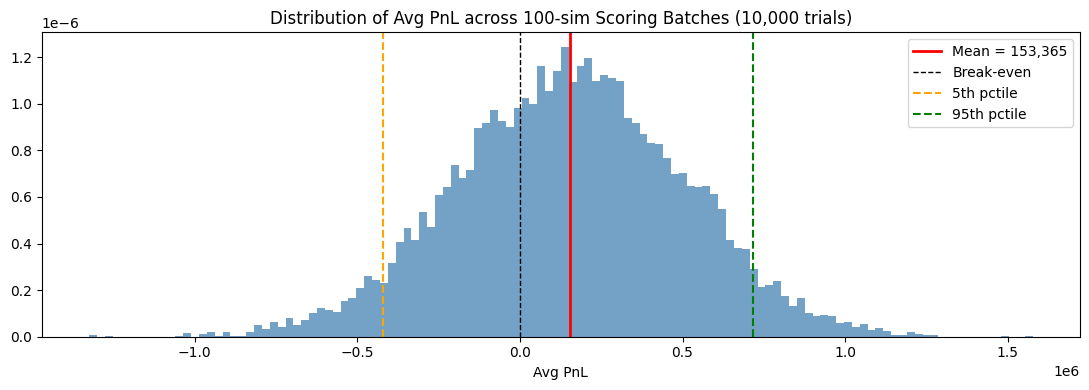

In [10]:
PAYOFF_FNS = {
    'AC_50_C':   lambda s2,s3,sm: np.maximum(s3 - 50, 0),
    'AC_50_P':   lambda s2,s3,sm: np.maximum(50 - s3, 0),
    'AC_35_P':   lambda s2,s3,sm: np.maximum(35 - s3, 0),
    'AC_40_P':   lambda s2,s3,sm: np.maximum(40 - s3, 0),
    'AC_45_P':   lambda s2,s3,sm: np.maximum(45 - s3, 0),
    'AC_60_C':   lambda s2,s3,sm: np.maximum(s3 - 60, 0),
    'AC_50_C_2': lambda s2,s3,sm: np.maximum(s2 - 50, 0),
    'AC_50_P_2': lambda s2,s3,sm: np.maximum(50 - s2, 0),
    'AC_50_CO':  lambda s2,s3,sm: np.where(s2 >= 50,
                                            np.maximum(s3-50, 0),
                                            np.maximum(50-s3, 0)),
    'AC_40_BP':  lambda s2,s3,sm: 10.0 * (s3 < 40),
    'AC_45_KO':  lambda s2,s3,sm: np.where(sm > 35, np.maximum(45-s3,0), 0.0),
}

def portfolio_pnl(paths, positions, STEPS_2W, STEPS_3W, CONTRACT_SIZE):
    s2  = paths[:, STEPS_2W]
    s3  = paths[:, STEPS_3W]
    sm  = paths.min(axis=1)
    tot = np.zeros(paths.shape[0])
    for name, pos in positions.items():
        d, v, p = pos['dir'], pos['vol'], pos['price']
        pay = PAYOFF_FNS[name](s2, s3, sm)
        tot += d * (pay - p) * v * CONTRACT_SIZE
    return tot

# ── Simulate 10,000 independent 100-sim batches ───────────────────
N_BATCHES = 10_000
batch_avgs = np.empty(N_BATCHES)

for i in range(N_BATCHES):
    p100 = simulate_paths(S0, SIGMA, 100, STEPS_3W, seed=i)
    batch_avgs[i] = portfolio_pnl(p100, positions, STEPS_2W, STEPS_3W, CONTRACT_SIZE).mean()

print('100-sim Batch Statistics (10,000 runs):')
print(f'  Mean avg PnL : {batch_avgs.mean():>12,.0f}')
print(f'  Std  avg PnL : {batch_avgs.std():>12,.0f}')
print(f'  P(avg > 0)   : {(batch_avgs > 0).mean():.4f}')
print(f'  1st  pctile  : {np.percentile(batch_avgs,  1):>12,.0f}')
print(f'  5th  pctile  : {np.percentile(batch_avgs,  5):>12,.0f}')
print(f'  25th pctile  : {np.percentile(batch_avgs, 25):>12,.0f}')
print(f'  Median       : {np.percentile(batch_avgs, 50):>12,.0f}')
print(f'  75th pctile  : {np.percentile(batch_avgs, 75):>12,.0f}')
print(f'  95th pctile  : {np.percentile(batch_avgs, 95):>12,.0f}')
print(f'  99th pctile  : {np.percentile(batch_avgs, 99):>12,.0f}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(batch_avgs, bins=120, density=True, color='steelblue', alpha=0.75)
ax.axvline(batch_avgs.mean(), color='red',    linewidth=2, label=f'Mean = {batch_avgs.mean():,.0f}')
ax.axvline(0,                 color='black',  linewidth=1, linestyle='--', label='Break-even')
ax.axvline(np.percentile(batch_avgs, 5),  color='orange', linewidth=1.5, linestyle='--', label='5th pctile')
ax.axvline(np.percentile(batch_avgs, 95), color='green',  linewidth=1.5, linestyle='--', label='95th pctile')
ax.set_title('Distribution of Avg PnL across 100-sim Scoring Batches (10,000 trials)')
ax.set_xlabel('Avg PnL'); ax.legend()
plt.tight_layout(); plt.show()

## 10 — Strategy Comparison

In [11]:
strategies = {
    'Chooser arb only': {
        'AC_50_CO':  {'dir':-1,'vol':50, 'price':22.200},
        'AC_50_C':   {'dir':+1,'vol':50, 'price':12.050},
        'AC_50_P_2': {'dir':+1,'vol':50, 'price': 9.750},
    },
    '+ Binary put sell': {
        'AC_50_CO':  {'dir':-1,'vol':50, 'price':22.200},
        'AC_50_C':   {'dir':+1,'vol':50, 'price':12.050},
        'AC_50_P_2': {'dir':+1,'vol':50, 'price': 9.750},
        'AC_40_BP':  {'dir':-1,'vol':50, 'price': 5.000},
    },
    '+ 2wk call': {
        'AC_50_CO':  {'dir':-1,'vol':50, 'price':22.200},
        'AC_50_C':   {'dir':+1,'vol':50, 'price':12.050},
        'AC_50_P_2': {'dir':+1,'vol':50, 'price': 9.750},
        'AC_40_BP':  {'dir':-1,'vol':50, 'price': 5.000},
        'AC_50_C_2': {'dir':+1,'vol':50, 'price': 9.750},
    },
    '+ KO put buy': positions,   # full strategy
    '+ KO sell (wrong way)': {
        **{k:v for k,v in positions.items() if k != 'AC_45_KO'},
        'AC_45_KO': {'dir':-1,'vol':500,'price':0.150},
    },
}

print(f'{"Strategy":<30} {"E[PnL]":>12} {"Std":>12} {"Sharpe":>8} {"P(avg>0) 100sim":>16}')
print('─' * 85)

N_COMPARE = 100_000
p_large   = simulate_paths(S0, SIGMA, N_COMPARE, STEPS_3W, seed=42)

for sname, spos in strategies.items():
    pnl_s  = portfolio_pnl(p_large, spos, STEPS_2W, STEPS_3W, CONTRACT_SIZE)
    mu, sd = pnl_s.mean(), pnl_s.std()
    sharpe = mu / sd if sd > 0 else 0
    # Estimate P(100-sim avg > 0) analytically
    se_100 = sd / np.sqrt(100)
    p_pos  = norm.cdf(mu / se_100)
    print(f'{sname:<30} {mu:>12,.0f} {sd:>12,.0f} {sharpe:>8.4f} {p_pos:>16.4f}')

Strategy                             E[PnL]          Std   Sharpe  P(avg>0) 100sim
─────────────────────────────────────────────────────────────────────────────────────
Chooser arb only                     59,379    1,457,927   0.0407           0.6581
+ Binary put sell                    96,009    1,916,800   0.0501           0.6918
+ 2wk call                          124,393    3,806,137   0.0327           0.6281
+ KO put buy                        174,553    3,475,974   0.0502           0.6922
+ KO sell (wrong way)                39,460    3,404,330   0.0116           0.5461


## 11 — Sensitivity Analysis

Portfolio E[PnL] vs σ:
 sigma    E[PnL]       Std
   1.5 1053008.9 2926484.0
   1.7  800069.9 2960652.7
   1.9  598242.1 3035649.9
   2.1  431760.8 3150029.7
   2.3  288461.1 3288339.6
   2.5  156208.7 3464856.0
   2.7   45438.8 3681656.4
   2.9  -53249.2 3936955.1
   3.1 -145159.2 4234203.4
   3.3 -225370.9 4572857.1


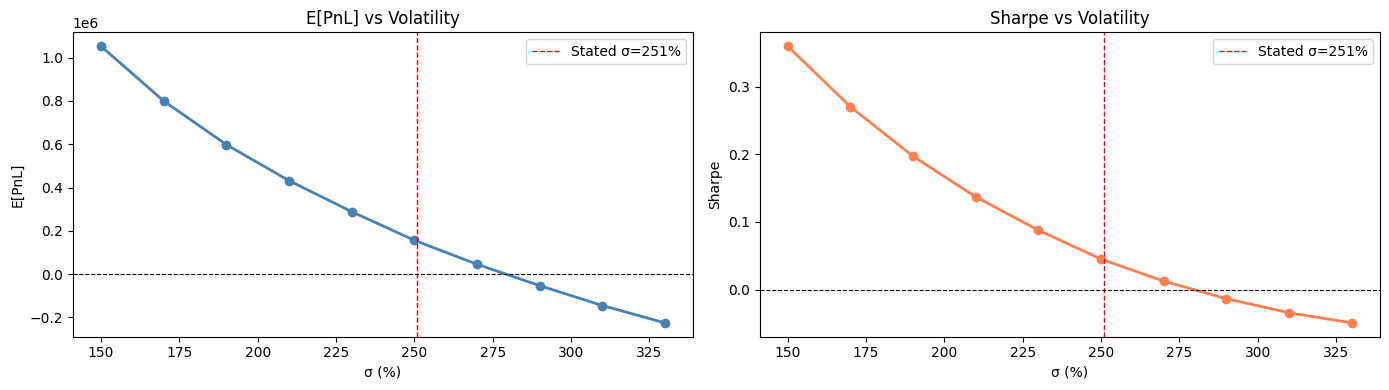


Per-product edge decomposition (300k sims):
Product        Fair(MC)  Trade   Edge/u       E[PnL]  Var contrib
──────────────────────────────────────────────────────────────────────
AC_50_CO        21.8663   SELL   0.3337       50,062 13,760,164,161,309
AC_50_C         11.9789    BUY  -0.0711      -10,660 15,421,402,778,298
AC_50_P_2        9.8753    BUY   0.1253       18,802 2,709,978,080,193
AC_40_BP         4.7686   SELL   0.2314       34,705 561,295,562,975
AC_50_C_2        9.8553    BUY   0.1053       15,797 8,815,361,664,476
AC_45_KO         0.2064    BUY   0.0314       47,044 2,659,070,545,234
AC_60_C          8.7465   SELL   0.0535        8,024 12,305,608,449,661


In [12]:
# ── Vol sensitivity ──────────────────────────────────────────────
test_vols = np.arange(1.5, 3.5, 0.2)
ev_results = []

for sig in test_vols:
    p_test = simulate_paths(S0, sig, 100_000, STEPS_3W, seed=7)
    pnl_t  = portfolio_pnl(p_test, positions, STEPS_2W, STEPS_3W, CONTRACT_SIZE)
    ev_results.append({'sigma': sig, 'E[PnL]': pnl_t.mean(), 'Std': pnl_t.std()})

ev_df = pd.DataFrame(ev_results)
print('Portfolio E[PnL] vs σ:')
print(ev_df.to_string(index=False, float_format='{:.1f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ev_df['sigma']*100, ev_df['E[PnL]'], 'steelblue', linewidth=2, marker='o')
axes[0].axvline(251, color='red', linewidth=1, linestyle='--', label='Stated σ=251%')
axes[0].axhline(0,   color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('E[PnL] vs Volatility'); axes[0].set_xlabel('σ (%)')
axes[0].set_ylabel('E[PnL]'); axes[0].legend()

axes[1].plot(ev_df['sigma']*100, ev_df['E[PnL]']/ev_df['Std'], 'coral', linewidth=2, marker='o')
axes[1].axvline(251, color='red', linewidth=1, linestyle='--', label='Stated σ=251%')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Sharpe vs Volatility'); axes[1].set_xlabel('σ (%)')
axes[1].set_ylabel('Sharpe'); axes[1].legend()
plt.tight_layout(); plt.show()

# ── Per-product contribution ─────────────────────────────────────
print('\nPer-product edge decomposition (300k sims):')
p_full = simulate_paths(S0, SIGMA, 300_000, STEPS_3W, seed=42)
s2_f, s3_f, sm_f = p_full[:,STEPS_2W], p_full[:,STEPS_3W], p_full.min(axis=1)

print(f'{"Product":<13} {"Fair(MC)":>9} {"Trade":>6} {"Edge/u":>8} {"E[PnL]":>12} {"Var contrib":>12}')
print('─' * 70)
for name, pos in positions.items():
    d, v, p = pos['dir'], pos['vol'], pos['price']
    pay   = PAYOFF_FNS[name](s2_f, s3_f, sm_f)
    fv    = pay.mean()
    edge  = (fv - p) * d
    pnl_i = d * (pay - p) * v * CONTRACT_SIZE
    ev    = pnl_i.mean()
    var   = pnl_i.var()
    action = 'SELL' if d < 0 else 'BUY'
    print(f'{name:<13} {fv:>9.4f} {action:>6} {edge:>8.4f} {ev:>12,.0f} {var:>12,.0f}')

## 12 — Final Trading Summary

In [13]:
print('=' * 75)
print('FINAL TRADES — Round 4 Manual Trading')
print('=' * 75)

final = [
    ('AC_50_CO',  'SELL', 50,   22.200, 'Chooser arb (overpriced vs replication)'),
    ('AC_50_C',   'BUY',  50,   12.050, 'Arb leg: long 3wk call'),
    ('AC_50_P_2', 'BUY',  50,    9.750, 'Arb leg: long 2wk put'),
    ('AC_40_BP',  'SELL', 50,    5.000, 'Binary put overpriced (~0.23 edge)'),
    ('AC_50_C_2', 'BUY',  50,    9.750, '2wk call underpriced (~0.11 edge)'),
    ('AC_45_KO',  'BUY',  500,   0.175, 'KO put underpriced (~0.031 edge, high vol)'),
    ('AC_60_C',   'SELL', 50,    8.800, '60C slight edge (~0.05)'),
]

print(f'\n{"Product":<13} {"Action":>6} {"Vol":>5} {"Price":>7} {"Fair":>8} {"Edge/u":>8} {"E[PnL]":>12}')
print('─' * 70)
grand_ev = 0
for prod, action, vol, price, reason in final:
    fv   = mc_fv[prod]
    d    = -1 if action == 'SELL' else +1
    edge = (fv - price) * d
    ev   = edge * vol * CONTRACT_SIZE
    grand_ev += ev
    print(f'{prod:<13} {action:>6} {vol:>5} {price:>7.3f} {fv:>8.4f} {edge:>8.4f} {ev:>12,.0f}')
    print(f'    └─ {reason}')

print('─' * 70)
print(f'{"EXPECTED PnL (MC fair)":>50} {grand_ev:>12,.0f}')

# Final 1M-sim estimate
p1M  = simulate_paths(S0, SIGMA, 1_000_000, STEPS_3W, seed=0)
pnl1M = portfolio_pnl(p1M, positions, STEPS_2W, STEPS_3W, CONTRACT_SIZE)
print(f'\nLarge-sample (1M sims) validation:')
print(f'  E[PnL]       : {pnl1M.mean():>12,.0f}')
print(f'  Std[PnL]     : {pnl1M.std():>12,.0f}')
print(f'  Sharpe/trade : {pnl1M.mean()/pnl1M.std():>12.4f}')

se_100 = pnl1M.std() / np.sqrt(100)
p_pos  = norm.cdf(pnl1M.mean() / se_100)
print(f'  P(100-sim avg > 0): {p_pos:.4f}')

print('\n' + '=' * 75)
print('RISK NOTES')
print('=' * 75)
print('  1. Chooser arb: net payoff ≈ 0 but not exactly 0 due to discrete steps.')
print('     Residual variance is from (S3 - S2 | S2 < 50 case). Zero-mean.')
print('  2. Binary put short: max loss = 5.00/unit if S3 crashes below 40.')
print('     P(S3 < 40) ≈ 0.48 per sim path. Negative correlation with KO put.')
print('  3. KO put long: highly path-dependent. ~61% of paths get knocked out.')
print('     Provides some offset to binary put losses in crash scenarios.')
print('  4. With only 100 scoring sims, realized PnL has high variance (~350k std).')
print('     P(positive avg score) ≈ 0.67.')

FINAL TRADES — Round 4 Manual Trading

Product       Action   Vol   Price     Fair   Edge/u       E[PnL]
──────────────────────────────────────────────────────────────────────
AC_50_CO        SELL    50  22.200  21.8663   0.3337       50,062
    └─ Chooser arb (overpriced vs replication)
AC_50_C          BUY    50  12.050  11.9789  -0.0711      -10,660
    └─ Arb leg: long 3wk call
AC_50_P_2        BUY    50   9.750   9.8753   0.1253       18,802
    └─ Arb leg: long 2wk put
AC_40_BP        SELL    50   5.000   4.7686   0.2314       34,705
    └─ Binary put overpriced (~0.23 edge)
AC_50_C_2        BUY    50   9.750   9.8553   0.1053       15,797
    └─ 2wk call underpriced (~0.11 edge)
AC_45_KO         BUY   500   0.175   0.2064   0.0314       47,044
    └─ KO put underpriced (~0.031 edge, high vol)
AC_60_C         SELL    50   8.800   8.7465   0.0535        8,024
    └─ 60C slight edge (~0.05)
──────────────────────────────────────────────────────────────────────
                     